In [2]:
import matplotlib.pyplot as plt
import MLMC
import numpy as np

Nmin=30
M0=32
s=2

In [10]:
(result, Y_L, N_vals)=MLMC.MLMC(Nmin, M0, s)

KeyboardInterrupt: 

Below is the code for generating the plots.
First the plot for the variance

(5,)


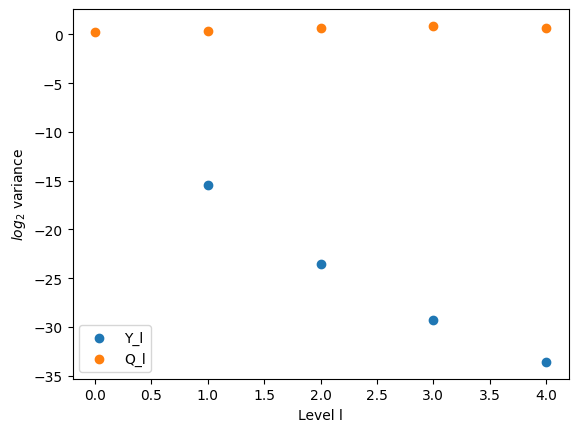

[9.38976710e-03 2.31052891e-05 7.89699635e-08 1.57115611e-09
 7.72590581e-11]
[1.22712677 1.29032901 1.53836996 1.83556012 1.57556782]


In [ ]:
N_vals=16*np.exp2(np.arange(5)).astype(int)#TODO: Remove
sample_num=200
#Compute Q_L variance
Q_L=np.empty((N_vals.size, sample_num))
Q_vars=np.empty(N_vals.shape)

print(N_vals.shape)
for l in range(N_vals.size):
    M=M0*(s**l)
    Q_L[l]=MLMC.draw_Q_L_samples(M, sample_num)
    Q_vars[l]=Q_L[l].var()
#Compute variances of Y_L
Y_L=[np.empty(sample_num)]*len(N_vals)#TODO: Remove
Y_vars=np.empty(len(Y_L))
for l in range(len(Y_L)):
    Y_L[l]=MLMC.draw_Y_L_samples(16, 2, sample_num, l)
    Y_vars[l]=np.var(Y_L[l])
#Compute grid sizes
L_vals=np.arange(N_vals.size)
plt.scatter(L_vals[1:], np.log2(Y_vars[1:]), label="Y_l")
plt.scatter(L_vals, np.log2(Q_vars), label="Q_l")
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$log _2$ variance")
plt.show()


Now the plot for the means

Text(0, 0.5, '$log_2$ |mean|')

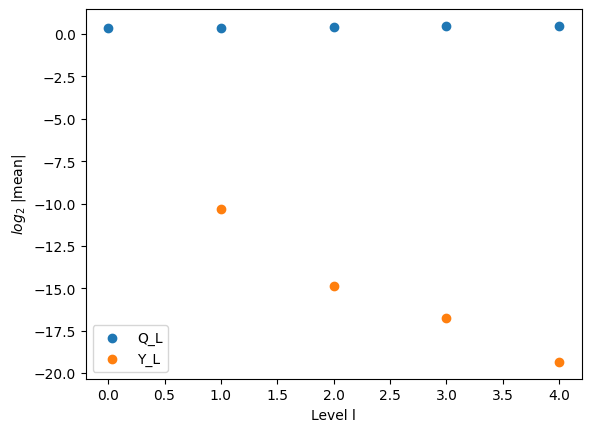

In [11]:
Q_means=np.empty(Q_vars.shape)
for l in range(Q_L.shape[0]):
    Q_means[l]=Q_L[l].mean()
Y_means=np.empty(len(Y_L)-1)
for l in range(1, len(Y_L)):
    Y_means[l-1]=np.mean(Y_L[l])
plt.scatter(L_vals, np.log2(np.abs(Q_means)), label="Q_L")
plt.scatter(L_vals[1:], np.log2(np.abs(Y_means)), label="Y_L")
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$log_2$ |mean|")

Generating Y_L samples with new grid size 64:   0%|          | 0/100 [00:00<?, ?it/s]

-2.0509493971704178e-05
-4.433648315409655e-05
-2.4693874828885242e-05


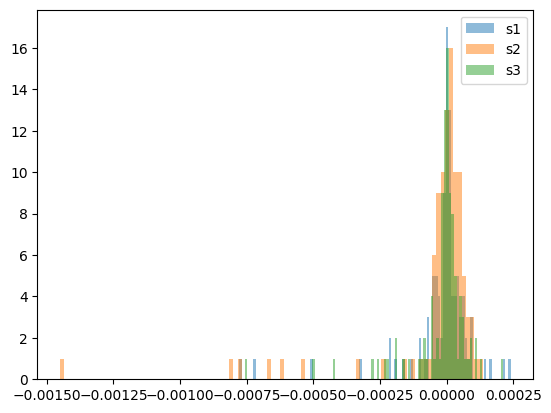

In [ ]:
s1=MLMC.draw_Y_L_samples(16, 2, 1000, 2)
s2=MLMC.draw_Y_L_samples(16, 2, 1000, 2)
s3=MLMC.draw_Y_L_samples(16, 2, 1000, 2)
print(np.mean(s1))
print(np.mean(s2))
print(np.mean(s3))

plt.hist(s1, 1000, alpha=0.5, label="s1")
plt.hist(s2, 1000, alpha=0.5, label="s2")
plt.hist(s3, 1000, alpha=0.5, label="s3")
plt.legend()
plt.show()

